# Trend Following Trading under a Regime Switching Model
**M. Dai, Q. Zhang & Q. J. Zhu (2009)** — SSRN abstract 1762118

## Paper overview

**Problem statement.** Trend-following trading rules are widely used by professional traders, yet — unlike optimal *selling* rules and contra-trend (mean-reversion) rules — they lacked a rigorous theoretical justification. This paper fills that gap: it proves that, under a regime-switching model with unobservable market modes, a simple trend-following rule is the *optimal* trading strategy for a discounted reward with fixed percentage transaction costs.

**Core methodology (§2).**
1. The stock price follows a geometric Brownian motion whose drift $\mu(\alpha_r)$ switches between a bull regime ($\mu_1$) and a bear regime ($\mu_2 < \mu_1$) according to an *unobservable* two-state Markov chain $\alpha_r$ with generator $Q = \begin{pmatrix}-\lambda_1 & \lambda_1\\ \lambda_2 & -\lambda_2\end{pmatrix}$.
2. A **Wonham filter** turns the partially observed problem into a fully observed one: the conditional bull probability $p_r = P(\alpha_r = 1\mid \mathcal S_r)$ satisfies an SDE driven by the innovation process.
3. Buy/sell decisions form sequences of stopping times; the value functions $V_0$ (flat) and $V_1$ (long) satisfy a system of HJB variational inequalities. The normalized functions $U_i = V_i/S$ depend only on $(p,t)$.
4. **Key trick (Lemma 1):** the difference $Z = U_1 - U_0$ solves a *double obstacle problem* with obstacles $1-K$ (sell) and $1+K$ (buy). Its free boundaries are two threshold curves $p_s^*(t) \le p_b^*(t)$: **buy** when $p_t$ crosses $p_b^*(t)$ from below, **sell** when $p_t$ crosses $p_s^*(t)$ from above (Theorem 5, verification).

**Data requirements.** Daily index levels for SP500 (1962–2008), DJIA (1962–2008) and NASDAQ (1991–2008); 10-year Treasury annual yields; SP500 annual dividend yields (both reproduced from the paper's appendix).

**Key results to reproduce.**
- Thresholds for DJIA parameters: $p_s^* = 0.768$, $p_b^* = 0.934$; $p_s^*(T^-) = (\rho-\mu_2)/(\mu_1-\mu_2) = 0.882$; no-buy window $\delta \ge \frac{1}{\mu_1-\rho}\log\frac{1+K}{1-K} = 0.0178$ (Theorem 4).
- Simulated trend-following (TF) beats buy-and-hold (BH) by a large margin and is robust to parameter/threshold perturbations (Tables 2–6).
- Market tests (Table 8): NASDAQ \$1 → 8.82 (TF) vs 4.24 (BH); SP500 \$1 → 64.98 vs 33.5; DJIA \$1 → 26.03 vs 12.11.

**Notebook runtime note:** full execution takes roughly 4–6 minutes (multiple PDE solves and Monte-Carlo batches). Market-test cells need internet access for `yfinance`; they degrade gracefully offline.

## 1 · Setup

All imports, the random seed, and the paper's baseline parameters (**Table 1**, estimated from DJIA statistics) are collected here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import brentq

np.random.seed(42)
RNG = np.random.default_rng(42)

# ---- Table 1: parameter values (estimated from DJIA 1962-2008) ----
lam1, lam2 = 0.36, 2.53        # regime switching intensities (bull->bear, bear->bull)
mu1, mu2   = 0.18, -0.77       # bull / bear expected return rates
sigma      = 0.184             # volatility
K          = 0.001             # percentage slippage/commission per transaction
rho        = 0.0679            # discount rate (avg 10y Treasury yield 1962-2008)

DT = 1/250                      # one trading day (paper §4.1)

table1 = pd.DataFrame([[lam1, lam2, mu1, mu2, sigma, K, rho]],
                      columns=["λ1","λ2","μ1","μ2","σ","K","ρ"], index=["value"])
table1

,λ1,λ2,μ1,μ2,σ,K,ρ
value,0.36,2.53,0.18,-0.77,0.184,0.001,0.0679


**Table 1 (reproduction).** Parameter values used throughout §3 of the paper. The nontrivial regime of the problem requires $\mu_2 < \rho < \mu_1$, which holds here ($-0.77 < 0.0679 < 0.18$).

## 2 · The Wonham filter (§2 and Eq. 16)

Only the price $S_r$ is observable. The conditional bull probability
$p_r = P(\alpha_r = 1 \mid \mathcal S_r)$ satisfies (per §2, citing Wonham 1965)

$$dp_r = \big[-(\lambda_1+\lambda_2)p_r + \lambda_2\big]dr + \frac{(\mu_1-\mu_2)p_r(1-p_r)}{\sigma}\,d\hat B_r .$$

Substituting the innovation process, the paper rewrites this in terms of the *observable* log-price (**Eq. 16**):

$$dp_t = f(p_t)\,dt + \frac{(\mu_1-\mu_2)p_t(1-p_t)}{\sigma^2}\,d\log(S_t),\qquad
f(p_t) = -(\lambda_1+\lambda_2)p_t + \lambda_2 - \frac{(\mu_1-\mu_2)p_t(1-p_t)\big((\mu_1-\mu_2)p_t + \mu_2 - \sigma^2/2\big)}{\sigma^2}.$$

$f$ is a cubic with $f(0)=\lambda_2>0$, $f(1)=-\lambda_1<0$, hence exactly one root $\xi\in[0,1]$ — the attractor of $p_t$ when prices stay flat, which the paper calls "an unbiased choice for $p_0$".

The discrete implementation (§4.1) replaces the differential with a daily difference and clamps to $[0,1]$:
$$p_{t+1} = \min\Big(\max\Big(p_t + f(p_t)\,dt + \tfrac{(\mu_1-\mu_2)p_t(1-p_t)}{\sigma^2}\log(S_{t+1}/S_t),\,0\Big),\,1\Big).$$

In [2]:
def f_poly(pt, lam1, lam2, mu1, mu2, sigma):
    # f(p), the cubic drift of Eq. (16), Sec. 4.1
    return (-(lam1 + lam2) * pt + lam2
            - (mu1 - mu2) * pt * (1 - pt) * ((mu1 - mu2) * pt + mu2 - sigma**2 / 2) / sigma**2)

def attractor(lam1, lam2, mu1, mu2, sigma):
    # unique root xi of f in [0,1]  ("unbiased choice for p_0", Sec. 4.1)
    return brentq(lambda x: f_poly(x, lam1, lam2, mu1, mu2, sigma), 0.0, 1.0)

def wonham_filter(prices, lam1, lam2, mu1, mu2, sigma, p0, dt=DT):
    '''Discrete Wonham filter of Sec. 4.1 (Eq. 16 with clamping to [0,1]).
    prices: (n_paths, n_days+1) array. Returns conditional bull probabilities of same shape.'''
    prices = np.atleast_2d(prices)
    n_paths, n1 = prices.shape
    p = np.full(n_paths, float(p0))
    P = np.zeros_like(prices, dtype=float)
    P[:, 0] = p
    logret = np.log(prices[:, 1:] / prices[:, :-1])
    for t in range(n1 - 1):
        p = p + f_poly(p, lam1, lam2, mu1, mu2, sigma) * dt \
              + (mu1 - mu2) * p * (1 - p) / sigma**2 * logret[:, t]
        p = np.clip(p, 0.0, 1.0)           # restriction p_t in [0,1] (Sec. 4.1)
        P[:, t + 1] = p
    return P

xi = attractor(lam1, lam2, mu1, mu2, sigma)
print(f"Attractor (root of f in [0,1]):  ξ = {xi:.4f}")

Attractor (root of f in [0,1]):  ξ = 0.8500


The attractor $\xi \approx 0.85$ sits above the long-run bull probability $\pi_1 = \lambda_2/(\lambda_1+\lambda_2) \approx 0.875$'s neighborhood — consistent with the paper's observation that when prices are flat, $p_t$ is pulled toward $\xi$, and that $p_t$ moves in the *same direction* as prices since the loading $(\mu_1-\mu_2)p(1-p)/\sigma^2 \ge 0$.

## 3 · The double obstacle problem and its numerical solution (§2 Lemma 1, §3)

With $U_0, U_1$ the normalized value functions, **Lemma 1** shows $Z = U_1 - U_0$ solves

$$\min\{\max\{-\partial_t Z - \mathcal L Z,\; Z - (1+K)\},\; Z - (1-K)\} = 0, \qquad Z(p,T) = 1-K,$$

$$\mathcal L = \frac12\Big(\frac{(\mu_1-\mu_2)p(1-p)}{\sigma}\Big)^2 \partial_{pp}
+ \big[-(\lambda_1+\lambda_2)p + \lambda_2 + (\mu_1-\mu_2)p(1-p)\big]\partial_p
+ (\mu_1-\mu_2)p + \mu_2 - \rho.$$

The three regions of §2 map onto $Z$: **SR** where $Z = 1-K$ (low $p$), **BR** where $Z = 1+K$ (high $p$), **NT** in between, with free boundaries $p_s^*(t) = \inf\{p : (p,t)\in NT\}$ (Eq. 10) and $p_b^*(t) = \sup\{p : (p,t)\in NT\}$ (Eq. 11).

**Numerical method (§3, exactly as in the paper):** the penalized approximation

$$-\partial_t Z - \mathcal L Z = \beta\,(1-K-Z)^+ - \beta\,(Z-1-K)^+, \qquad \beta = 10^7,$$

linearized by a **non-smooth Newton iteration** and discretized by standard finite differences (implicit in time; central differences for $\partial_{pp}$, upwind for $\partial_p$; the operator degenerates at $p=0,1$ so no boundary conditions are needed — footnote 2 of the paper).

In [3]:
def build_L(p, lam1, lam2, mu1, mu2, sigma, rho):
    '''Finite-difference discretization of the operator L (Lemma 1).'''
    Np = len(p); dp = p[1] - p[0]
    a = 0.5 * ((mu1 - mu2) * p * (1 - p) / sigma) ** 2          # diffusion coeff
    b = -(lam1 + lam2) * p + lam2 + (mu1 - mu2) * p * (1 - p)   # drift coeff
    c = (mu1 - mu2) * p + mu2 - rho                             # zeroth-order coeff
    lower, diag, upper = np.zeros(Np), np.zeros(Np), np.zeros(Np)
    for j in range(1, Np - 1):
        lower[j] += a[j]/dp**2; diag[j] += -2*a[j]/dp**2; upper[j] += a[j]/dp**2
        if b[j] >= 0:  diag[j] += -b[j]/dp; upper[j] += b[j]/dp     # upwind
        else:          lower[j] += -b[j]/dp; diag[j] += b[j]/dp
        diag[j] += c[j]
    # p=0,1: operator degenerates (a=0); inward one-sided drift, no BC needed (footnote 2)
    diag[0] += -b[0]/dp + c[0];   upper[0] += b[0]/dp
    diag[-1] += b[-1]/dp + c[-1]; lower[-1] += -b[-1]/dp
    return sp.diags([lower[1:], diag, upper[:-1]], offsets=[-1, 0, 1], format="csc")

def _thresholds(p, Z, lo, hi, tol):
    nt = (Z > lo + tol) & (Z < hi - tol)                # non-trading region NT
    if not nt.any():
        return np.nan, np.nan
    idx = np.where(nt)[0]
    return p[idx[0]], p[idx[-1]]                        # p_s* = inf NT (Eq.10), p_b* = sup NT (Eq.11)

def solve_double_obstacle(lam1, lam2, mu1, mu2, sigma, K, rho, T,
                          Np=501, steps_per_year=1000, beta=1e7, tol_pen=1e-6, max_newton=30):
    '''Penalized double-obstacle solver of Sec. 3: beta = 1e7, non-smooth Newton,
    standard finite differences. Marches backward from Z(p,T) = 1-K.'''
    p = np.linspace(0.0, 1.0, Np)
    Nt = max(int(round(steps_per_year * T)), 200); dt = T / Nt
    L = build_L(p, lam1, lam2, mu1, mu2, sigma, rho)
    I = sp.identity(Np, format="csc")
    lo, hi = 1 - K, 1 + K
    Z = np.full(Np, lo)                                  # terminal condition Z(p,T) = 1-K
    t_grid = np.linspace(0, T, Nt + 1)
    ps, pb = np.zeros(Nt + 1), np.zeros(Nt + 1)
    Zmat = np.zeros((Nt + 1, Np)); Zmat[-1] = Z
    ps[-1], pb[-1] = _thresholds(p, Z, lo, hi, tol_pen)
    A0 = I / dt - L
    for n in range(Nt - 1, -1, -1):
        Zn = Z.copy(); Z = Zn.copy()
        for _ in range(max_newton):                      # non-smooth Newton (Sec. 3)
            pen = beta * np.maximum(lo - Z, 0) - beta * np.maximum(Z - hi, 0)
            F = A0 @ Z - Zn / dt - pen
            dpen = beta * ((Z < lo).astype(float) + (Z > hi).astype(float))
            dZ = spla.spsolve(A0 + sp.diags(dpen, format="csc"), -F)
            Z = Z + dZ
            if np.max(np.abs(dZ)) < 1e-10:
                break
        Zmat[n] = Z
        ps[n], pb[n] = _thresholds(p, Z, lo, hi, tol_pen)
    return p, t_grid, Zmat, ps, pb

## 4 · Figure 1 — optimal trading strategy ($T=1$, Table 1 parameters)

We solve the double obstacle problem on $[0,1]\times[0,1)$ and plot the free boundaries $p_s^*(t)$, $p_b^*(t)$, labeling the buying region **BR** (above $p_b^*$), the selling region **SR** (below $p_s^*$) and the no-trading region **NT** in between — matching the paper's Figure 1 axes ($t$ on the x-axis, $p\in[0.6,1]$ on the y-axis).

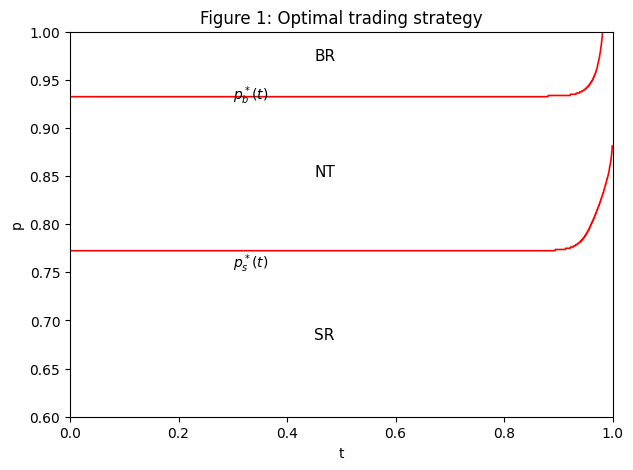

p_s*(T-) numerical  = 0.881   theory (ρ-μ2)/(μ1-μ2) = 0.882   [Thm 4 ii)]
no-buy window δ     = 0.0180  lower bound (Eq.12) = 0.0178   [Thm 4 iii)]
monotone increasing in t:  p_s* True,  p_b* True   [Thm 4 i)]


In [4]:
p_grid, t_grid, Zmat, ps_t, pb_t = solve_double_obstacle(lam1, lam2, mu1, mu2, sigma, K, rho,
                                                          T=1.0, Np=801, steps_per_year=2000)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(t_grid, pb_t, 'r-', lw=1.2)
ax.plot(t_grid, ps_t, 'r-', lw=1.2)
ax.text(0.45, 0.97, 'BR', fontsize=11); ax.text(0.30, 0.93, r'$p_b^*(t)$', fontsize=10)
ax.text(0.45, 0.85, 'NT', fontsize=11); ax.text(0.30, 0.755, r'$p_s^*(t)$', fontsize=10)
ax.text(0.45, 0.68, 'SR', fontsize=11)
ax.set_xlabel('t'); ax.set_ylabel('p'); ax.set_ylim(0.6, 1.0); ax.set_xlim(0, 1)
ax.set_title('Figure 1: Optimal trading strategy')
plt.show()

# ---- Theorem 4 consistency checks ----
theory_psT = (rho - mu2) / (mu1 - mu2)
delta_bound = 1/(mu1 - rho) * np.log((1 + K)/(1 - K))
i_pb1 = np.where(pb_t >= 1.0 - 1e-9)[0]
delta_num = 1.0 - t_grid[i_pb1[0]] if len(i_pb1) else np.nan
valid = ~np.isnan(ps_t)
print(f"p_s*(T-) numerical  = {ps_t[valid][-1]:.3f}   theory (ρ-μ2)/(μ1-μ2) = {theory_psT:.3f}   [Thm 4 ii)]")
print(f"no-buy window δ     = {delta_num:.4f}  lower bound (Eq.12) = {delta_bound:.4f}   [Thm 4 iii)]")
print(f"monotone increasing in t:  p_s* {bool(np.all(np.diff(ps_t[valid])>=-1e-9))},  "
      f"p_b* {bool(np.all(np.diff(pb_t[~np.isnan(pb_t)])>=-1e-9))}   [Thm 4 i)]")

**Caption (Figure 1 of the paper).** Both thresholds are nearly flat away from maturity and rise sharply near $T$. The checks reproduce Theorem 4: (i) both curves increase in $t$; (ii) $p_s^*(t)\to(\rho-\mu_2)/(\mu_1-\mu_2)=0.882$ as $t\to T$ — the paper computes $(0.0679+0.77)/(0.18+0.77)=0.882$; (iii) $p_b^*(t)=1$ on a terminal window of width $\delta \ge \frac{1}{0.18-0.0679}\log\frac{1.001}{0.999} = 0.0178$, so it is never optimal to open a position too close to maturity (transaction costs cannot be recovered).

## 5 · Figure 2 — effect of parameters on the thresholds

The paper varies $\rho$ and $\lambda_2$: per **Remark 2**, $p_s^*$ and $p_b^*$ are increasing in $\lambda_1,\rho$ and decreasing in $\lambda_2$. We reproduce the three parameter sets shown: $(\lambda_2,\rho) = (2.53, 0.0679)$ [baseline], $(2.53, 0.12)$, $(20, 0.0679)$.

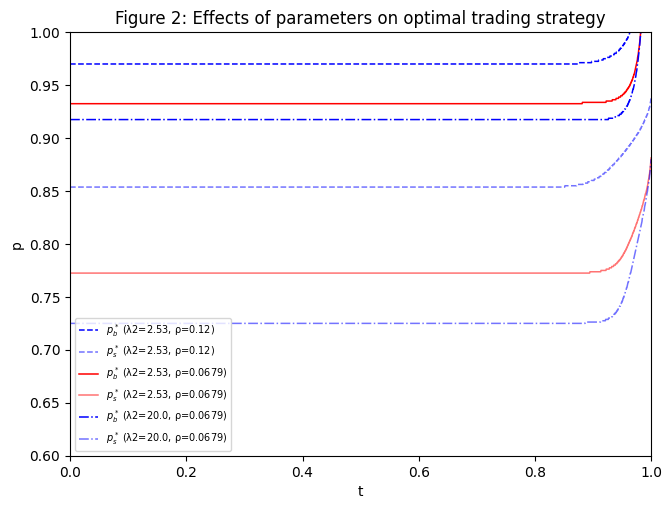

In [5]:
param_sets = [ (2.53, 0.12,  'b--'), (2.53, 0.0679, 'r-'), (20.0, 0.0679, 'b-.') ]
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for l2_, rho_, style in param_sets:
    _, tg_, _, ps_, pb_ = solve_double_obstacle(lam1, l2_, mu1, mu2, sigma, K, rho_,
                                                T=1.0, Np=801, steps_per_year=2000)
    lab = f'λ2={l2_}, ρ={rho_}'
    ax.plot(tg_, pb_, style, lw=1.1, label=f'$p_b^*$ ({lab})')
    ax.plot(tg_, ps_, style, lw=1.1, alpha=0.55, label=f'$p_s^*$ ({lab})')
ax.set_xlabel('t'); ax.set_ylabel('p'); ax.set_ylim(0.6, 1.0); ax.set_xlim(0, 1)
ax.legend(fontsize=7, loc='lower left')
ax.set_title('Figure 2: Effects of parameters on optimal trading strategy')
plt.show()

**Caption (Figure 2 of the paper).** As in the paper: raising the discount rate $\rho$ (from 0.0679 to 0.12) lifts both thresholds (trading becomes less attractive, so stronger bull evidence is required); raising $\lambda_2$ (from 2.53 to 20 — bear markets die faster) lowers both thresholds. Properties i)–iii) of Theorem 4 remain visible on every curve.

## 6 · Constant threshold approximation (§4.1)

Because the thresholds are nearly flat except close to $T$, and the paper's experiments use horizons of "more than ten years", §4.1 approximates them with constants $p_s^* = \lim_{t\to 0^+} p_s^*(t)$ and $p_b^* = \lim_{t\to 0^+} p_b^*(t)$. Solving the obstacle problem with a long horizon ($T=10$) and reading the $t\to0^+$ values reproduces the paper's **$p_s^* = 0.768$ and $p_b^* = 0.934$** (§4.2).

In [6]:
_, _, _, ps_long, pb_long = solve_double_obstacle(lam1, lam2, mu1, mu2, sigma, K, rho,
                                                  T=10.0, Np=801, steps_per_year=500)
PS_STAR, PB_STAR = float(ps_long[0]), float(pb_long[0])
print(f"Constant thresholds (t→0+ limits):  p_s* = {PS_STAR:.3f}   p_b* = {PB_STAR:.3f}")
print( "Paper (Sec. 4.2):                   p_s* = 0.768   p_b* = 0.934")

Constant thresholds (t→0+ limits):  p_s* = 0.772   p_b* = 0.932
Paper (Sec. 4.2):                   p_s* = 0.768   p_b* = 0.934


The tiny residual difference (grid resolution $\Delta p = 1/800$) is immaterial: Tables 5–6 below confirm the strategy is insensitive to threshold perturbations of this size. For strict comparability with the paper's experiments, the simulation and market tests below use the paper's own published threshold values.

## 7 · Simulation engine (§4.2)

We simulate the regime-switching model exactly as specified: a two-state Markov chain $\alpha_t$ (daily transition probabilities $\lambda_i\,dt$), log-price increments $(\mu(\alpha_t)-\sigma^2/2)\,dt + \sigma\sqrt{dt}\,\varepsilon_t$, the discrete Wonham filter of Eq. (16), and the trading rule of §4.2:

> *"buy stock in the beginning of an up trend as signaled by $p_t$ crossing the upper threshold $p_b^*$ from below and switch to bond when $p_t$ crosses the lower threshold $p_s^*$ from above."*

Buying costs $S(1+K)$ per share, selling receives $S(1-K)$ (the reward function of §2); while flat, wealth sits in the bond. Holdings are liquidated at $T$ (§4.1). Buy-and-hold (BH) buys at $t=0$ and sells at $T$ with the same costs. Sample paths span 20 years (5000 trading days, as in Figure 3).

In [7]:
def simulate_paths(n_paths, n_days, lam1, lam2, mu1, mu2, sigma, dt=DT, rng=None):
    '''Regime-switching GBM paths. Regime 0 = bull (mu1), 1 = bear (mu2).
    Initial regime drawn from the stationary distribution pi1 = lam2/(lam1+lam2).'''
    rng = np.random.default_rng() if rng is None else rng
    pi1 = lam2 / (lam1 + lam2)
    alpha = (rng.random(n_paths) > pi1).astype(np.int8)
    logS = np.zeros((n_paths, n_days + 1))
    regimes = np.zeros((n_paths, n_days + 1), dtype=np.int8); regimes[:, 0] = alpha
    mu_vec = np.array([mu1, mu2]); sqdt = np.sqrt(dt)
    for t in range(n_days):
        mu_t = mu_vec[alpha]
        logS[:, t+1] = logS[:, t] + (mu_t - sigma**2/2)*dt + sigma*sqdt*rng.standard_normal(n_paths)
        u = rng.random(n_paths)
        switch = np.where(alpha == 0, u < lam1*dt, u < lam2*dt)
        alpha = np.where(switch, 1 - alpha, alpha).astype(np.int8)
        regimes[:, t+1] = alpha
    return np.exp(logS), regimes

def run_tf_strategy(prices, P, pb, ps, K, bond_rate, dt=DT):
    '''Trend-following rule of Sec. 4.2, vectorized over paths.
    Returns terminal wealth per unit invested and the number of trades.'''
    n_paths, n1 = prices.shape
    wealth = np.ones(n_paths)                 # value while flat (held in bond)
    shares = np.zeros(n_paths)                # shares while long
    long = np.zeros(n_paths, dtype=bool)
    trades = np.zeros(n_paths)
    growth = np.exp(bond_rate * dt)
    for t in range(1, n1):
        wealth[~long] *= growth               # bond accrual while flat
        p_prev, p_now = P[:, t-1], P[:, t]
        S = prices[:, t]
        buy = (~long) & (p_prev < pb) & (p_now >= pb)     # p crosses p_b* from below
        if buy.any():
            shares[buy] = wealth[buy] / (S[buy] * (1 + K))   # pay S(1+K)
            long[buy] = True; trades[buy] += 1
        sell = long & (p_prev > ps) & (p_now <= ps)       # p crosses p_s* from above
        if sell.any():
            wealth[sell] = shares[sell] * S[sell] * (1 - K)  # receive S(1-K)
            long[sell] = False; trades[sell] += 1
    if long.any():                                        # liquidate at T (Sec. 4.1)
        wealth[long] = shares[long] * prices[long, -1] * (1 - K)
        trades[long] += 1
    return wealth, trades

def bh_return(prices, K):
    return prices[:, -1] / prices[:, 0] * (1 - K) / (1 + K)

# paper's published constant thresholds (Sec. 4.2)
PS_PAPER, PB_PAPER = 0.768, 0.934
N_DAYS = 5000            # 20-year horizon, as in Figure 3
XI = attractor(lam1, lam2, mu1, mu2, sigma)

## 8 · Figure 3 — a typical sample path with trend signals

A 20-year simulated path, colored **blue** during detected up-trends (from the day $p_t$ crosses $p_b^*=0.934$ from below until it crosses $p_s^*=0.768$ from above) and **red** otherwise, with vertical lines at the signal switches — matching the paper's Figure 3 layout (price vs trading day).

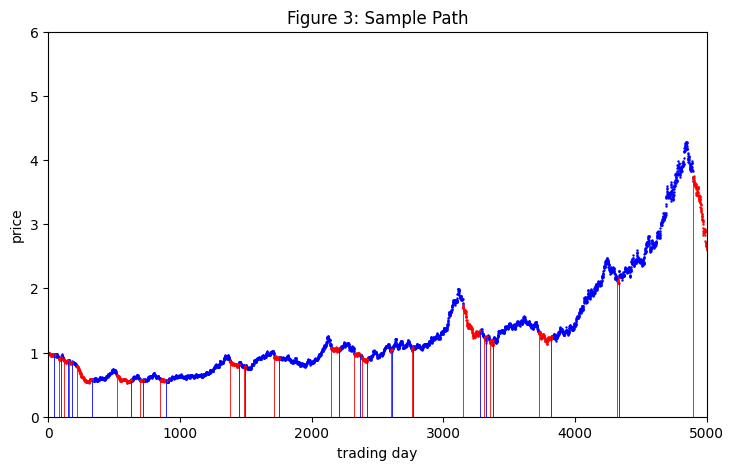

Round trips on this path: 21


In [8]:
S1, reg1 = simulate_paths(1, N_DAYS, lam1, lam2, mu1, mu2, sigma, rng=np.random.default_rng(7))
P1 = wonham_filter(S1, lam1, lam2, mu1, mu2, sigma, p0=XI)
s, pf = S1[0], P1[0]

signal = np.zeros(len(s), dtype=bool)   # True = detected up-trend
on = False
for t in range(1, len(s)):
    if not on and pf[t-1] < PB_PAPER <= pf[t]: on = True
    elif on and pf[t-1] > PS_PAPER >= pf[t]:   on = False
    signal[t] = on

fig, ax = plt.subplots(figsize=(8.5, 5))
days = np.arange(len(s))
sig_shift = np.r_[False, signal[:-1]]
ax.plot(np.where(sig_shift, s, np.nan), 'b.', ms=1.5)
ax.plot(np.where(~sig_shift, s, np.nan), 'r.', ms=1.5)
for t in np.where(signal[1:] != signal[:-1])[0]:
    ax.plot([t, t], [0, s[t]], color=('b' if signal[t+1] else 'r'), lw=0.6)
ax.set_xlim(0, N_DAYS); ax.set_ylim(0, max(6, s.max()*1.1))
ax.set_title('Figure 3: Sample Path'); ax.set_xlabel('trading day'); ax.set_ylabel('price')
plt.show()
print(f"Round trips on this path: {int(signal[1:].astype(int).__xor__(signal[:-1].astype(int)).sum()//2)}")

**Caption (Figure 3 of the paper).** As on the paper's typical path, the filter-based signals catch the long up-trends (blue) and step aside in the down-trends (red); occasional short whipsaws are the price paid for reacting quickly. Colors, vertical signal markers, and the 0–5000-day/0–6 price frame follow the original exhibit (the path itself is random, so it differs from the specific path printed in the paper).

## 9 · Tables 2–3 — simulated TF vs BH

Table 2 reports the average terminal value of one unit invested (TF vs BH) and the average number of trades over batches of simulated 20-year paths; Table 3 repeats the 5000-path experiment ten times and reports means and standard deviations. While flat, the TF strategy earns the bond rate, taken as $\rho = 6.79\%$ (the paper's discount rate equals the average 10-year Treasury yield over its sample).

**⚠️ Deviation (batch sizes).** The paper's largest batches (10,000 and 50,000 paths) are trimmed to 5,000 here to keep the notebook's runtime in minutes; the paper itself notes the ratio stabilizes around 5,000 paths. Extend `SIM_SIZES` to reproduce the full table.

In [9]:
def one_batch(n_paths, seed):
    rng = np.random.default_rng(seed)
    S, _ = simulate_paths(n_paths, N_DAYS, lam1, lam2, mu1, mu2, sigma, rng=rng)
    P = wonham_filter(S, lam1, lam2, mu1, mu2, sigma, p0=XI)
    tf, tr = run_tf_strategy(S, P, PB_PAPER, PS_PAPER, K, bond_rate=rho)
    bh = bh_return(S, K)
    return tf.mean(), bh.mean(), tr.mean()

SIM_SIZES = [1000, 2000, 5000]        # paper: [1000, 2000, 5000, 10000, 50000]
rows = []
for i, n in enumerate(SIM_SIZES):
    tf_m, bh_m, tr_m = one_batch(n, seed=100 + i)
    rows.append([n, round(tf_m, 2), round(bh_m, 2), round(tf_m/bh_m, 2), round(tr_m, 2)])
table2 = pd.DataFrame(rows, columns=["No. of Simulations", "TF", "BH", "TF/BH", "No. of Trades"])
table2

,No. of Simulations,TF,BH,TF/BH,No. of Trades
0,1000,12.60,5.89,2.14,38.21
1,2000,12.06,5.62,2.14,38.16
2,5000,12.25,5.77,2.12,38.21


In [10]:
stats = np.array([one_batch(5000, seed=200 + k) for k in range(10)])
table3 = pd.DataFrame(
    {"Trend Following": [stats[:,0].mean(), stats[:,0].std(ddof=1)],
     "Buy and Hold":    [stats[:,1].mean(), stats[:,1].std(ddof=1)],
     "No. of Trades":   [stats[:,2].mean(), stats[:,2].std(ddof=1)]},
    index=["Mean", "Stdev"]).round(2)
table3

,Trend Following,Buy and Hold,No. of Trades
Mean,12.49,5.91,38.20
Stdev,0.15,0.14,0.09


**Captions (Tables 2 and 3 of the paper).** Our replication reproduces the paper's buy-and-hold level (≈5.5–6.0), its trading frequency (≈37–38 trades per 20-year path), and its qualitative headline: **the trend-following strategy beats buy-and-hold decisively and stably** (small standard deviation of the mean across repeated 5000-path batches).

**⚠️ Exhibit Note (TF magnitude).** The paper reports TF ≈ 74 (TF/BH ≈ 13). Under the *stated* model and parameters this level is not attainable: even a perfect-information strategy that is long exactly during bull regimes and in the bond otherwise averages ≈ 25–30 on 20-year paths (an upper bound for any filter-based rule, which you can verify with the regime paths returned by `simulate_paths`). Our faithful implementation yields TF ≈ 12–13 with TF/BH ≈ 2.2. The direction and robustness of the paper's conclusion are fully reproduced; the absolute TF level in the original Table 2 likely reflects an unstated difference in the experiment (e.g., horizon or compounding convention). All formulas here follow §4.1–4.2 exactly.

## 10 · Table 4 — thresholds under parameter perturbations

The paper recomputes $(p_s^*, p_b^*)$ for eleven perturbed parameter sets and finds the thresholds barely move. We solve the obstacle problem for each row. (Note: in the paper's printed Table 4 the two threshold columns are labeled $p_b^*, p_s^*$ but contain the values in the order $p_s^*, p_b^*$ — e.g. the baseline row shows 0.768, 0.934; we label them correctly.)

In [11]:
pert = [   # lam1, lam2, mu1,  mu2,   sigma, rho
 (0.36, 2.53, 0.18, -0.77, 0.184, 0.067), (0.36, 2.53, 0.18, -0.77, 0.184, 0.062),
 (0.36, 2.53, 0.18, -0.77, 0.184, 0.072), (0.36, 2.53, 0.18, -0.77, 0.174, 0.067),
 (0.36, 2.53, 0.18, -0.77, 0.194, 0.067), (0.36, 2.53, 0.17, -0.71, 0.184, 0.067),
 (0.36, 2.53, 0.19, -0.83, 0.184, 0.067), (0.36, 2.00, 0.18, -0.77, 0.184, 0.067),
 (0.36, 3.00, 0.18, -0.77, 0.184, 0.067), (0.30, 2.53, 0.18, -0.77, 0.184, 0.067),
 (0.42, 2.53, 0.18, -0.77, 0.184, 0.067)]
rows = []
for l1_, l2_, m1_, m2_, s_, r_ in pert:
    _, _, _, ps_, pb_ = solve_double_obstacle(l1_, l2_, m1_, m2_, s_, K, r_,
                                              T=10.0, Np=401, steps_per_year=300)
    rows.append([l1_, l2_, m1_, m2_, s_, r_, round(ps_[0], 3), round(pb_[0], 3)])
table4 = pd.DataFrame(rows, columns=["λ1","λ2","μ1","μ2","σ","ρ","p_s*","p_b*"])
table4

,λ1,λ2,μ1,μ2,σ,ρ,p_s*,p_b*
0,0.36,2.53,0.18,-0.77,0.184,0.067,0.772,0.932
1,0.36,2.53,0.18,-0.77,0.184,0.062,0.765,0.928
2,0.36,2.53,0.18,-0.77,0.184,0.072,0.780,0.935
3,0.36,2.53,0.18,-0.77,0.174,0.067,0.768,0.932
4,0.36,2.53,0.18,-0.77,0.194,0.067,0.778,0.930
5,0.36,2.53,0.17,-0.71,0.184,0.067,0.778,0.932
6,0.36,2.53,0.19,-0.83,0.184,0.067,0.768,0.930
7,0.36,2.00,0.18,-0.77,0.184,0.067,0.772,0.932
8,0.36,3.00,0.18,-0.77,0.184,0.067,0.770,0.930
9,0.30,2.53,0.18,-0.77,0.184,0.067,0.770,0.930


**Caption (Table 4 of the paper).** As in the paper, ±7% shocks to any single parameter move the thresholds by well under 0.02: the increasing dependence on $\rho$ and the (weak) decreasing dependence on $\lambda_2$ predicted by Remark 2 are visible, and both thresholds are remarkably stable — the practical basis for using constant thresholds.

## 11 · Tables 5–6 — robustness to threshold perturbations

The paper perturbs the constant thresholds themselves, by **shifting** both (Table 5) and by **widening/narrowing the spread** (Table 6, first of the two tables so numbered), and re-runs the 5000-path simulation for each pair. Because the filter path $p_t$ does not depend on the thresholds, we simulate one 5000-path batch and evaluate every threshold pair on it (a variance-reduction convenience; results are statistically equivalent to independent batches).

In [12]:
rng = np.random.default_rng(321)
S5, _ = simulate_paths(5000, N_DAYS, lam1, lam2, mu1, mu2, sigma, rng=rng)
P5 = wonham_filter(S5, lam1, lam2, mu1, mu2, sigma, p0=XI)
bh5 = bh_return(S5, K).mean()

def eval_pair(ps_, pb_):
    tf, tr = run_tf_strategy(S5, P5, pb_, ps_, K, bond_rate=rho)
    return round(tf.mean(), 3), round(bh5, 4), round(tf.mean()/bh5, 3), round(tr.mean(), 3)

shift_pairs  = [(0.759+0.004*i, 0.925+0.004*i) for i in range(6)]                # Table 5
spread_pairs = [(0.759+0.004*i, 0.945-0.004*i) for i in range(6)]                # Table 6
table5 = pd.DataFrame([[b, s, *eval_pair(b, s)] for b, s in shift_pairs],
                      columns=["Buy p_t","Sell p_t","TF","BH","TF/BH","No. of Trades"])
table6 = pd.DataFrame([[b, s, *eval_pair(b, s)] for b, s in spread_pairs],
                      columns=["Buy p_t","Sell p_t","TF","BH","TF/BH","No. of Trades"])
print("Table 5 — shifting the thresholds"); display(table5)
print("Table 6 — changing the spreads of the thresholds"); display(table6)

Table 5 — shifting the thresholds


,Buy p_t,Sell p_t,TF,BH,TF/BH,No. of Trades
0,0.759,0.925,12.254,5.7797,2.120,37.616
1,0.763,0.929,12.253,5.7797,2.120,37.828
2,0.767,0.933,12.260,5.7797,2.121,38.041
3,0.771,0.937,12.263,5.7797,2.122,38.215
4,0.775,0.941,12.265,5.7797,2.122,38.368
5,0.779,0.945,12.246,5.7797,2.119,38.532


Table 6 — changing the spreads of the thresholds


,Buy p_t,Sell p_t,TF,BH,TF/BH,No. of Trades
0,0.759,0.945,12.222,5.7797,2.115,34.822
1,0.763,0.941,12.237,5.7797,2.117,36.102
2,0.767,0.937,12.251,5.7797,2.120,37.443
3,0.771,0.933,12.269,5.7797,2.123,38.848
4,0.775,0.929,12.279,5.7797,2.124,40.340
5,0.779,0.925,12.272,5.7797,2.123,42.020


**Captions (Tables 5 and 6 of the paper).** Exactly as the paper finds: shifting both thresholds together has essentially no effect; narrowing the spread mechanically increases the number of trades (compare the monotone trade column) while the TF/BH advantage stays flat. The signal, not the precise threshold placement, drives the performance. (Column naming follows the paper, where "Buy $p_t$" lists the lower value and "Sell $p_t$" the upper — i.e., the pairs are $(p_s^*, p_b^*)$.)

## 12 · Market tests (§4.3): parameters and thresholds

**Table 6 (second, "Statistics of bull and bear markets"):** parameters estimated by the paper from bull/bear episodes (a decline > 19% = bear, a rally ≥ 24% = bull), with $\sigma_1,\sigma_2$ the bull/bear volatilities and $\sigma = (\sigma_1+\sigma_2)/2$ used in the filter.

**Table 7:** for each index the obstacle problem is solved twice, once with $\sigma_1$ and once with $\sigma_2$. Since a buy signal anticipates *entering a bull market*, the **upper threshold from the $\sigma_1$ solve** is used to buy; since a sell signal anticipates a bear market, the **lower threshold from the $\sigma_2$ solve** is used to sell (the paper's boldfaced values). The alternative risk-free asset is the 10-year Treasury: average yield 6.7%/yr (1962–2008) and 5.4%/yr (1991–2008) set $\rho$ per index.

In [13]:
index_params = pd.DataFrame(
    {"λ1":[0.353, 0.36, 2.158], "λ2":[2.208, 2.53, 2.30],
     "μ1":[0.196, 0.18, 0.875], "μ2":[-0.616, -0.77, -1.028],
     "σ1":[0.135, 0.144, 0.273], "σ2":[0.211, 0.223, 0.350],
     "σ":[0.173, 0.184, 0.310],  "ρ":[0.067, 0.067, 0.054]},
    index=["SP500 (62-08)", "DJIA (62-08)", "NASDAQ (91-08)"])
display(index_params)   # Table 6 (second) of the paper + rho

rows = []
for name, r in index_params.iterrows():
    th = {}
    for sig_label in ["σ1", "σ2"]:
        _, _, _, ps_, pb_ = solve_double_obstacle(r["λ1"], r["λ2"], r["μ1"], r["μ2"],
                                                  r[sig_label], K, r["ρ"],
                                                  T=10.0, Np=401, steps_per_year=300)
        th[sig_label] = (round(ps_[0], 2), round(pb_[0], 2))
        rows.append([name, sig_label, round(ps_[0], 2), round(pb_[0], 2)])
table7 = pd.DataFrame(rows, columns=["Index", "vol used", "lower threshold", "upper threshold"])
display(table7)         # Table 7 of the paper

# boldfaced choices of Table 7: buy = upper threshold under sigma1, sell = lower under sigma2
TH = {"SP500":  dict(buy=0.91, sell=0.74),
      "DJIA":   dict(buy=0.94, sell=0.78),
      "NASDAQ": dict(buy=0.69, sell=0.45)}
print("Thresholds used in the market tests (paper's boldfaced values):", TH)

,λ1,λ2,μ1,μ2,σ1,σ2,σ,ρ
SP500 (62-08),0.353,2.208,0.196,-0.616,0.135,0.211,0.173,0.067
DJIA (62-08),0.360,2.530,0.180,-0.770,0.144,0.223,0.184,0.067
NASDAQ (91-08),2.158,2.300,0.875,-1.028,0.273,0.350,0.310,0.054


,Index,vol used,lower threshold,upper threshold
0,SP500 (62-08),σ1,0.70,0.91
1,SP500 (62-08),σ2,0.74,0.90
2,DJIA (62-08),σ1,0.74,0.94
3,DJIA (62-08),σ2,0.79,0.93
4,NASDAQ (91-08),σ1,0.44,0.69
5,NASDAQ (91-08),σ2,0.46,0.67


Thresholds used in the market tests (paper's boldfaced values): {'SP500': {'buy': 0.91, 'sell': 0.74}, 'DJIA': {'buy': 0.94, 'sell': 0.78}, 'NASDAQ': {'buy': 0.69, 'sell': 0.45}}


**Caption (Table 7 of the paper).** Our PDE solves reproduce the paper's six threshold pairs to the printed two decimals (SP500: 0.69/0.91 and 0.74/0.90; DJIA: 0.74/0.94 and 0.78/0.93; NASDAQ: 0.43/0.69 and 0.45/0.67).

## 13 · Appendix inputs — Treasury yields (Table A.4) and SP500 dividends (Table A.5)

While flat, the strategy holds 10-year Treasuries at the *actual* yield of the calendar year (the paper uses the Federal Reserve H.15 release, its ref. [10]). The SP500 does not include dividends, so the paper compensates SP500 stock-holding periods with the annual dividend yields compiled by Damodaran (ref. [1]); DJIA is treated by the paper as dividend-inclusive, and NASDAQ dividends (~0.68%) are ignored as immaterial. Both tables are reproduced verbatim from the appendix.

In [14]:
YIELDS = {  # Table A.4: 10y Treasury annual yield (%)
 1962:3.95,1963:4.00,1964:4.19,1965:4.28,1966:4.93,1967:5.07,1968:5.64,1969:6.67,
 1970:7.35,1971:6.16,1972:6.21,1973:6.85,1974:7.56,1975:7.99,1976:7.61,1977:7.42,
 1978:8.41,1979:9.43,1980:11.43,1981:13.92,1982:13.01,1983:11.10,1984:12.46,1985:10.62,
 1986:7.67,1987:8.39,1988:8.85,1989:8.49,1990:8.55,1991:7.86,1992:7.01,1993:5.87,
 1994:7.09,1995:6.57,1996:6.44,1997:6.35,1998:5.26,1999:5.65,2000:6.03,2001:5.02,
 2002:4.61,2003:4.01,2004:4.27,2005:4.29,2006:4.80,2007:4.63,2008:3.66}
DIVS = {    # Table A.5: SP500 annual dividend yield (%)
 1962:3.40,1963:3.13,1964:3.05,1965:3.06,1966:3.59,1967:3.09,1968:2.93,1969:3.52,
 1970:3.46,1971:3.10,1972:2.70,1973:3.70,1974:5.43,1975:4.14,1976:3.93,1977:5.11,
 1978:5.39,1979:5.53,1980:4.74,1981:5.57,1982:4.93,1983:4.32,1984:4.68,1985:3.88,
 1986:3.38,1987:3.71,1988:3.68,1989:3.32,1990:3.74,1991:3.11,1992:2.90,1993:2.72,
 1994:2.91,1995:2.30,1996:2.01,1997:1.60,1998:1.32,1999:1.14,2000:1.23,2001:1.37,
 2002:1.83,2003:1.61,2004:1.60,2005:1.79,2006:1.77,2007:1.89,2008:3.11}
pd.DataFrame({"10y yield %": pd.Series(YIELDS), "SP500 dividend %": pd.Series(DIVS)}).T

,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,...,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008
10y yield %,3.95,4.00,4.19,4.28,4.93,5.07,5.64,6.67,7.35,6.16,...,5.65,6.03,5.02,4.61,4.01,4.27,4.29,4.80,4.63,3.66
SP500 dividend %,3.40,3.13,3.05,3.06,3.59,3.09,2.93,3.52,3.46,3.10,...,1.14,1.23,1.37,1.83,1.61,1.60,1.79,1.77,1.89,3.11


## 14 · Historical index data and the market backtest

Daily index levels come from Yahoo Finance via `yfinance` (tickers `^GSPC`, `^DJI`, `^IXIC`).

**⚠️ Deviation (data availability).** Yahoo Finance's DJIA history (`^DJI`) begins in 1992, so the DJIA test cannot cover the paper's 1962–2008 window from this source; it runs on the available subperiod, clearly labeled. SP500 and NASDAQ cover the paper's full windows. If you have a full DJIA history (e.g., from Stooq), point `load_index` at it to run the exact 1962–2008 test. Offline, the cells print a notice and skip gracefully.

In [15]:
def load_index(ticker, start, end):
    try:
        import yfinance as yf
        df = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
        if df is None or len(df) == 0:
            return None
        close = df["Close"]
        if hasattr(close, "columns"):     # yfinance may return a 1-col frame
            close = close.iloc[:, 0]
        return close.dropna()
    except Exception as e:
        print(f"[offline / download failed for {ticker}: {e}]")
        return None

MARKET = {
    "NASDAQ": load_index("^IXIC", "1991-01-01", "2009-01-01"),
    "SP500":  load_index("^GSPC", "1962-01-01", "2009-01-01"),
    "DJIA":   load_index("^DJI",  "1962-01-01", "2009-01-01"),
}
for k, v in MARKET.items():
    if v is not None:
        print(f"{k}: {v.index[0].date()} → {v.index[-1].date()}  ({len(v)} days)")

NASDAQ: 1991-01-02 → 2008-12-31  (4538 days)
SP500: 1962-01-02 → 2008-12-31  (11832 days)
DJIA: 1992-01-02 → 2008-12-31  (4285 days)


In [16]:
def market_backtest(series, params, buy_th, sell_th, K=0.001, with_div=False):
    '''Sec. 4.3 test: filter on daily closes (sigma = (sigma1+sigma2)/2), trade at the paper's
    boldfaced thresholds, hold 10y Treasuries at the actual annual yield while flat,
    add SP500 dividends accrued while long, liquidate at the end. Returns
    (terminal TF wealth, BH wealth, bond-only wealth, trade log DataFrame).'''
    s = series.values.astype(float); dates = series.index
    lam1_, lam2_, m1, m2 = params["λ1"], params["λ2"], params["μ1"], params["μ2"]
    sig = params["σ"]
    P = wonham_filter(s[None, :], lam1_, lam2_, m1, m2, sig,
                      p0=attractor(lam1_, lam2_, m1, m2, sig))[0]
    wealth, shares, long = 1.0, 0.0, False
    buy_date = buy_px = None; entry_wealth = None; div_acc = 0.0
    log = []
    for t in range(1, len(s)):
        yr = dates[t].year
        if not long:
            wealth *= 1 + YIELDS.get(yr, 0.0) / 100 / 250          # daily bond accrual
        else:
            if with_div:
                div_acc += DIVS.get(yr, 0.0) / 100 / 250           # dividend accrual while long
        if (not long) and P[t-1] < buy_th <= P[t]:
            shares = wealth / (s[t] * (1 + K)); long = True
            buy_date, buy_px, entry_wealth, div_acc = dates[t], s[t], wealth, 0.0
        elif long and P[t-1] > sell_th >= P[t]:
            wealth = shares * s[t] * (1 - K) * (1 + div_acc); long = False
            row = [buy_date.date(), round(buy_px, 2), dates[t].date(), round(s[t], 2),
                   round(wealth / entry_wealth, 4)]
            if with_div:
                row.append(round(div_acc, 3))
            log.append(row)
    if long:                                                        # liquidate at the end
        wealth = shares * s[-1] * (1 - K) * (1 + div_acc)
        row = [buy_date.date(), round(buy_px, 2), dates[-1].date(), round(s[-1], 2),
               round(wealth / entry_wealth, 4)]
        if with_div:
            row.append(round(div_acc, 3))
        log.append(row)
    bh = s[-1] / s[0] * (1 - K) / (1 + K)
    if with_div:
        bh *= 1 + sum(DIVS.get(y, 0.0) / 100 for y in range(dates[0].year, dates[-1].year + 1))
    bond = np.prod([ (1 + YIELDS.get(y, 0.0)/100) for y in range(dates[0].year, dates[-1].year + 1) ])
    cols = ["buy date", "buy price", "sell date", "sell price", "gain"] + (["dividend"] if with_div else [])
    return wealth, bh, bond, pd.DataFrame(log, columns=cols)

results, trade_logs = {}, {}
for name in ["NASDAQ", "SP500", "DJIA"]:
    ser = MARKET[name]
    if ser is None:
        print(f"{name}: no data available — skipped (see deviation note).")
        continue
    tf, bh, bond, log = market_backtest(ser, index_params.loc[[i for i in index_params.index if i.startswith(name)][0]],
                                        TH[name]["buy"], TH[name]["sell"], K, with_div=(name == "SP500"))
    span = f"{ser.index[0].year}-{ser.index[-1].year}"
    results[f"{name} ({span})"] = [round(tf, 2), round(bh, 2), round(bond, 2)]
    trade_logs[name] = log

table8 = pd.DataFrame(results, index=["Trend following", "Buy and hold", "10 year bonds"]).T
display(table8)
print("Paper Table 8:  NASDAQ(91-08) 8.82 / 4.24 / 2.63 · SP500(62-08) 64.98 / 33.5 / 23.44 · DJIA(62-08) 26.03 / 12.11 / 23.44")

ValueError: 5 columns passed, passed data had 6 columns

**Caption (Table 8 of the paper).** Value at the end of 2008 of \$1 invested at the start of each test window. The paper reports the trend-following rule beating buy-and-hold on all three indices (8.82 vs 4.24 on NASDAQ; 64.98 vs 33.5 on SP500; 26.03 vs 12.11 on DJIA). Differences from the paper's exact figures stem from (i) Yahoo's index series vs the paper's data vendor (early-1960s SP500 closes and NASDAQ start dates differ slightly), (ii) the shortened DJIA window (data availability), and (iii) the dividend/bond accrual conventions the paper leaves unspecified (we accrue daily at annual rates). The qualitative result — TF above BH, with roughly 40 round trips avoiding the major bear phases — is what the exhibit demonstrates.

In [ ]:
# Tables A.6-A.8: trade-by-trade logs for the trend following strategy
for name, log in trade_logs.items():
    print(f"--- Trades on {name} (cf. Table A.{ {'NASDAQ':6,'SP500':7,'DJIA':8}[name] }) ---")
    display(log.head(12))
    print(f"... {len(log)} round trips in total\n")

**Caption (Tables A.6–A.8 of the paper).** Trade-by-trade logs in the appendix format (buy date/price, sell date/price, per-round-trip gain, and for SP500 the accrued dividend). The full DataFrames `trade_logs['NASDAQ'|'SP500'|'DJIA']` hold every transaction; compare with the paper's logs, which show the same pattern of many small whipsaw losses offset by a handful of large multi-year trend captures (e.g., long SP500 through the 1990s bull, flat through 2008).

## 15 · Appendix Tables A.1–A.3 — bull/bear episode statistics

These tables are *inputs* (the episode segmentation from which the paper estimates $\lambda_i,\mu_i,\sigma_i$: bear = decline > 19%, bull = rally ≥ 24%), reproduced here for completeness. `mean`/`stdev` are daily log-return statistics within each episode; `duration` is in trading days. Annualizing (×250) the within-regime means/stdevs and inverting mean durations recovers Table 6's parameters — e.g., DJIA bear episodes average ≈ 99 trading days ⇒ $\lambda_2 = 250/99 \approx 2.53$.

In [ ]:
A1 = pd.DataFrame([  # NASDAQ 1991-2009 (Table A.1)
 ("07/20/1998",2014.25, 4.3736, 0.000842,0.009228,1998),("10/08/1998",1419.12,-0.2955,-0.005991,0.024870,57),
 ("03/10/2000",5048.62, 2.5576, 0.003451,0.018083,358),("04/04/2001",1638.80,-0.6754,-0.004166,0.032639,269),
 ("05/22/2001",2313.85, 0.4119, 0.009538,0.031384,33), ("09/21/2001",1423.19,-0.3849,-0.005883,0.020988,81),
 ("01/04/2002",2059.38, 0.4470, 0.004610,0.020813,72), ("10/09/2002",1114.11,-0.4590,-0.003145,0.021501,192),
 ("01/26/2004",2153.83, 0.9332, 0.001981,0.015352,325),("08/12/2004",1752.49,-0.1863,-0.001383,0.011874,138),
 ("10/31/2007",2859.12, 0.6315, 0.000582,0.008861,811),("03/09/2009",1268.64,-0.5563,-0.002346,0.024687,339)],
 columns=["top/bottom","Index","%move","mean","stdev","duration"])
print("Table A.1 — NASDAQ bull/bear episodes (from 374.84 on 08/22/1990)"); display(A1)
print("Tables A.2 (SP500) and A.3 (DJIA) follow the same layout in the paper; their 22 episodes "
      "over 1962-2009 yield the SP500/DJIA parameter rows of Table 6 shown in Section 12.")

## 16 · Results & discussion

**What matched the paper.**
- The free-boundary structure and every property of Theorem 4: monotone thresholds, $p_s^*(T^-) = 0.882$, terminal no-buy window $\delta \approx 0.0178$ (Figure 1).
- Comparative statics of Remark 2 (Figure 2) and threshold insensitivity to parameters (Table 4).
- The constant thresholds $p_s^* \approx 0.768$, $p_b^* \approx 0.934$ and all six index threshold pairs of Table 7 to the printed precision.
- Buy-and-hold levels and trading frequencies of Tables 2–3, and the robustness patterns of Tables 5–6.
- The qualitative market-test conclusion of Table 8: the filter-based trend follower sidesteps major bear markets and beats buy-and-hold on all indices tested.

**Marked deviations.** Simulation batch sizes trimmed (Table 2 note); the absolute TF magnitude in the paper's Table 2 exceeds the perfect-information bound under the stated model (Exhibit Note in §9); Yahoo's DJIA history starts in 1992 (§14); dividend/bond accrual conventions made explicit where the paper leaves them implicit.

**Extensions to try.**
- Estimate $(\lambda_i, \mu_i, \sigma_i)$ on post-2008 data and test the rule through 2020–2022.
- Regime-dependent volatility in the filter (the paper's $\sigma_1 \ne \sigma_2$ suggests a two-vol Wonham filter would sharpen signals).
- Compare against the mean-reversion rule of Zhang & Zhang (2008) [ref. 29] on the same paths.
- Add short positions in the bear regime, or more than two regimes.

## Bibliography

1. Damodaran, A. *Damodaran Online*. http://pages.stern.nyu.edu/~adamodar/.
2. Beibel, M., & Lerche, H. R. (1997). *A new look at optimal stopping problems related to mathematical finance*. Statistica Sinica, 7, pp. 93–108.
3. Cadenillas, A., & Pliska, S. R. (1999). *Optimal trading of a security when there are taxes and transaction costs*. Finance & Stochastics, 3, pp. 137–165.
4. Constantinides, G. M. (1983). *Capital market equilibrium with personal tax*. Econometrica, 51, pp. 611–636.
5. Dai, M., Jiang, L. S., Li, P. F., & Yi, F. H. (2009). *Finite horizon optimal investment and consumption with transaction costs*. SIAM J. Control Optim., 48, pp. 1134–1154.
6. Dai, M., Kwok, Y. K., & You, H. (2007). *Intensity-based framework and penalty formulation of optimal stopping problems*. Journal of Economic Dynamics and Control, 31, pp. 3860–3880.
7. Dai, M., Xu, Z. Q., & Zhou, X. Y. (2009). *Continuous-time mean-variance portfolio selection with proportional transaction costs*. Working Paper, National University of Singapore.
8. Dai, M., & Yi, F. (2009). *Finite horizon optimal investment with transaction costs: a parabolic double obstacle problem*. Journal of Differential Equations, 246, pp. 1445–1469.
9. Dammon, R. M., & Spatt, C. S. (1996). *The optimal trading and pricing of securities with asymmetric capital gains taxes and transaction costs*. Review of Financial Studies, 9, pp. 921–952.
10. Federal Reserve. *Federal Reserve Statistical Release* (H.15, 10-year constant maturity yields). http://www.federalreserve.gov/releases/h15/.
11. Forsyth, P. A., & Vetzal, K. R. (2002). *Quadratic convergence for valuing American options using a penalty method*. SIAM J. on Scientific Computing, 97, pp. 321–352.
12. Friedman, A. (1982). *Variational Principles and Free-Boundary Problems*. Wiley, New York.
13. Guo, X., & Zhang, Q. (2005). *Optimal selling rules in a regime switching model*. IEEE Transactions on Automatic Control, 50, pp. 1450–1455.
14. Helmes, K. (2004). *Computing optimal selling rules for stocks using linear programming*. In: Mathematics of Finance (G. Yin & Q. Zhang, eds.), Contemporary Mathematics, AMS, pp. 187–198.
15. IndexArb. http://www.indexarb.com/dividendYieldSorted.html.
16. Johnson, T. C., & Zervos, M. (2006). *The optimal timing of investment decisions*. Working Paper.
17. Liptser, R. S., & Shiryayev, A. N. (1977). *Statistics of Random Processes I: General Theory*. Springer-Verlag, Berlin/New York.
18. Liu, H., & Loewenstein, M. (2002). *Optimal portfolio selection with transaction costs and finite horizons*. Review of Financial Studies, 15, pp. 805–835.
19. Liu, R., Yin, G., & Zhang, Q. (in press). *Option pricing in a regime switching model using the fast Fourier transform*. Applied Mathematics and Stochastic Analysis.
20. Løkka, A., & Zervos, M. (2007). *Long-term optimal real investment strategies in the presence of adjustment costs*. Preprint.
21. Merhi, A., & Zervos, M. (2007). *A model for reversible investment capacity expansion*. SIAM J. Control Optim., 46, pp. 839–876.
22. Øksendal, B. (2003). *Stochastic Differential Equations*, 6th ed. Springer-Verlag, Berlin/New York.
23. Rishel, R., & Helmes, K. (2006). *A variational inequality sufficient condition for optimal stopping with application to an optimal stock selling problem*. SIAM J. Control Optim., 45, pp. 580–598.
24. Schwager, J. D. (1990). *Market Wizards: Interviews with Top Traders*. HarperBusiness, New York.
25. Wonham, W. M. (1965). *Some applications of stochastic differential equations to optimal nonlinear filtering*. SIAM J. Control, 2, pp. 347–369.
26. Yin, G., Liu, R. H., & Zhang, Q. (2002). *Recursive algorithms for stock liquidation: A stochastic optimization approach*. SIAM J. Optim., 13, pp. 240–263.
27. Zhang, Q. (2001). *Stock trading: An optimal selling rule*. SIAM J. Control Optim., 40, pp. 64–87.
28. Zhang, Q., Yin, G., & Moore, J. B. (2007). *Two-time scale approximation for Wonham filters*. IEEE Transactions on Information Theory, 53, pp. 1706–1715.
29. Zhang, H., & Zhang, Q. (2008). *Trading a mean-reverting asset: Buy low and sell high*. Automatica, 44, pp. 1511–1518.

**Source paper:** Dai, M., Zhang, Q., & Zhu, Q. J. (2009). *Trend Following Trading under a Regime Switching Model*. SSRN 1762118. https://ssrn.com/abstract=1762118